Importar Librerías

In [2]:
from confluent_kafka import Consumer, Producer
import matplotlib.pyplot as plt
from io import StringIO
import pandas as pd

Productor

In [24]:
#Leer CSV
csv_file_path = 'data_empresas.csv'
df = pd.read_csv(csv_file_path)

producer = Producer({'bootstrap.servers': 'localhost:9092'})

for _, row in df.iterrows():
    message = f"{row['empresa']},{row['pais']},{row['precioLY']},{row['precioCY']}"
    producer.produce('testtopic', value=message)

producer.flush()

0

Consumidor

In [25]:
c = Consumer({'bootstrap.servers': 'localhost:9092', 'group.id': 'migrupo', 'auto.offset.reset': 'earliest'})
c.subscribe(['testtopic'])

plot_df = pd.DataFrame(columns=['empresa', 'pais', 'precioLY', 'precioCY'])

try:
    while True:
        msg = c.poll(1.0)
        if msg is None:
            print("No hay ningún mensaje")
            continue
        if msg.error():
            print('Error: {}'.format(msg.error()))
            continue
        
        message_data = StringIO(msg.value().decode('utf-8'))
        row_data = pd.read_csv(message_data, header=None, names=['empresa', 'pais', 'precioLY', 'precioCY'])

        plot_df = pd.concat([plot_df, row_data], ignore_index=True)
except KeyboardInterrupt:
    pass
finally:
    c.close()

No hay ningún mensaje
No hay ningún mensaje
No hay ningún mensaje
No hay ningún mensaje
No hay ningún mensaje
No hay ningún mensaje
No hay ningún mensaje
No hay ningún mensaje
No hay ningún mensaje
No hay ningún mensaje
No hay ningún mensaje
No hay ningún mensaje
No hay ningún mensaje
No hay ningún mensaje
No hay ningún mensaje
No hay ningún mensaje
No hay ningún mensaje
No hay ningún mensaje
No hay ningún mensaje
No hay ningún mensaje


In [26]:
print(plot_df)

      empresa    pais precioLY precioCY
0    Deloitte      UK        0       10
1   Microsoft     USA    10000       33
2        BBVA   Spain      100       12
3      Amazon  Brasil      230      111
4        BBVA   Spain      100       12
5    Deloitte      UK        0       10
6   Microsoft     USA    10000       33
7       Apple     USA       54       29
8   Accenture  France       77      120
9   Accenture  France       77      120
10   Deloitte      UK        0       10
11      Apple     USA       54       29
12     Amazon  Brasil      230      111
13  Accenture  France       77      120
14     Amazon  Brasil      230      111
15       BBVA   Spain      100       12
16     Amazon  Brasil      230      111
17      Apple     USA       54       29
18  Microsoft     USA    10000       33
19       BBVA   Spain      100       12
20   Deloitte      UK        0       10
21  Microsoft     USA    10000       33
22      Apple     USA       54       29
23  Accenture  France       77      120


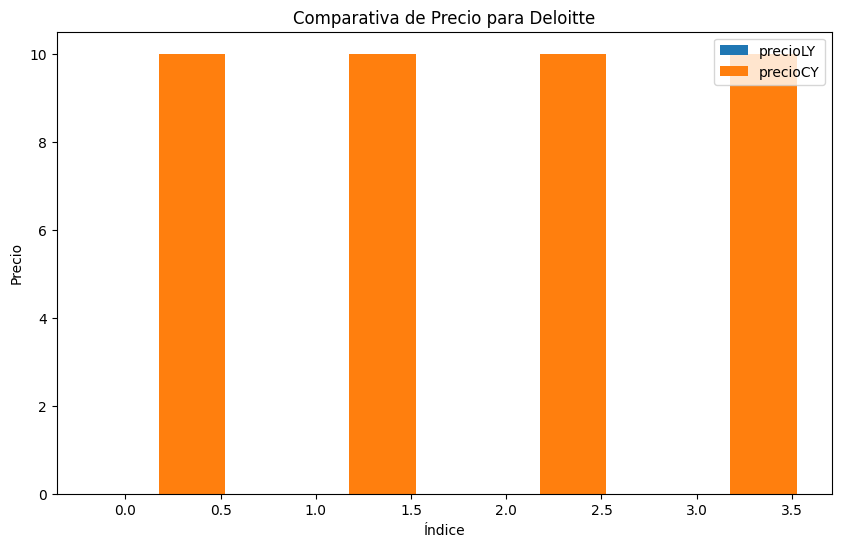

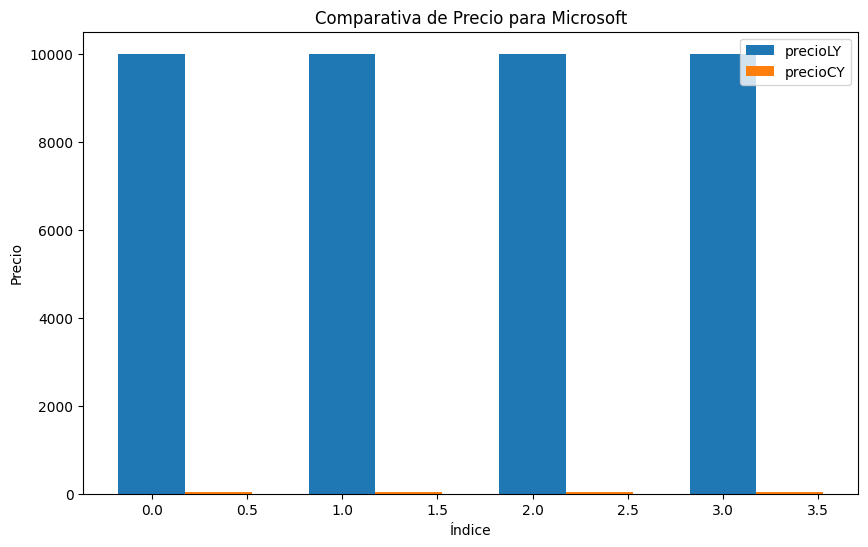

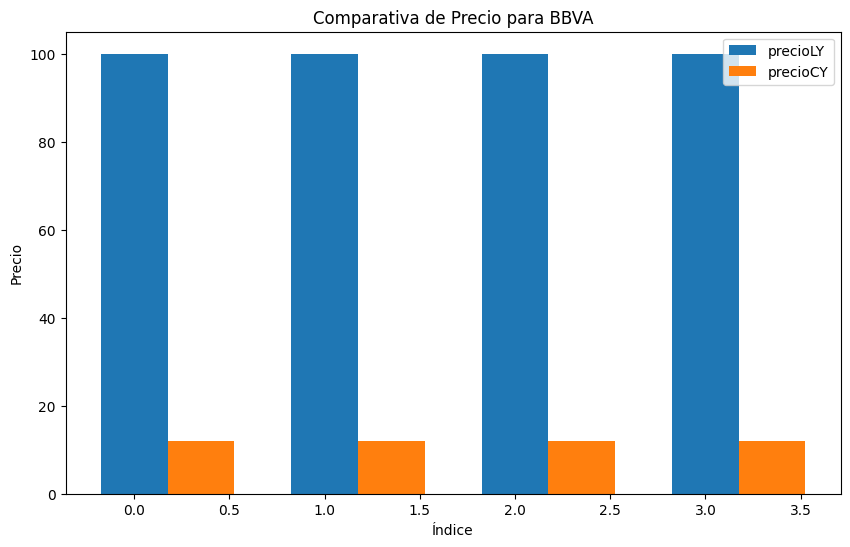

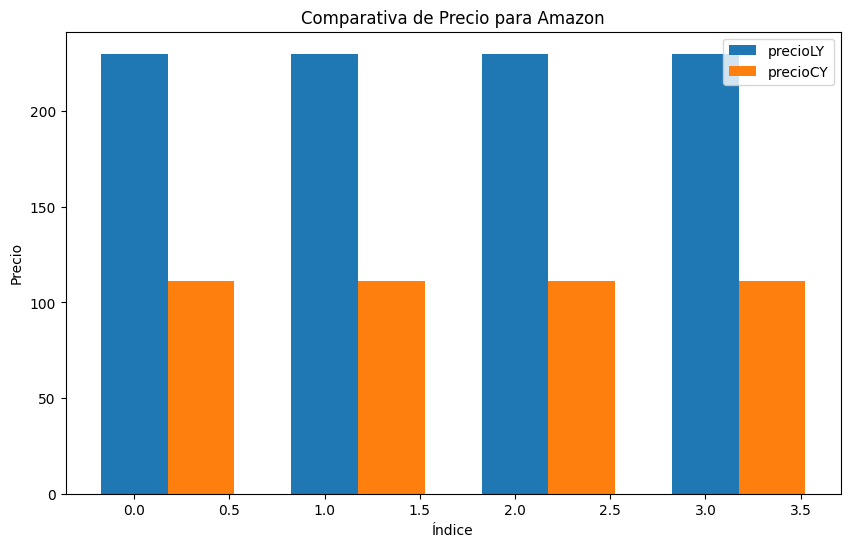

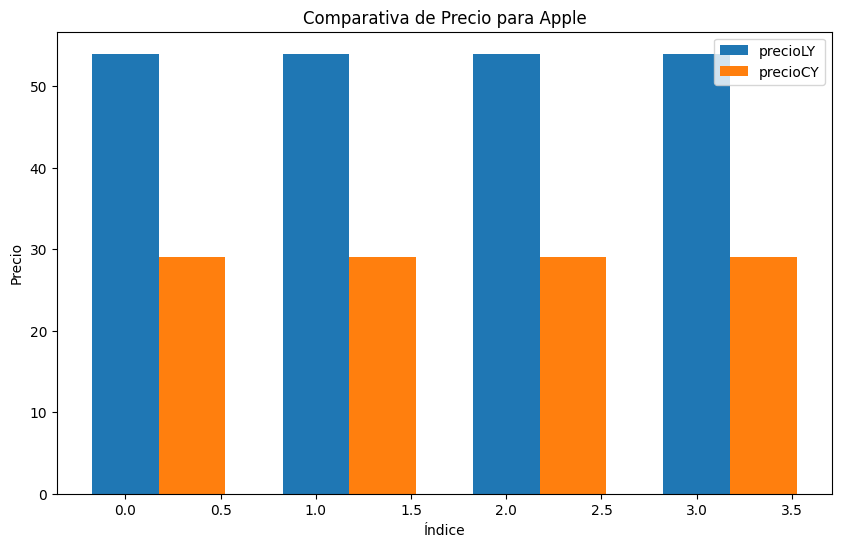

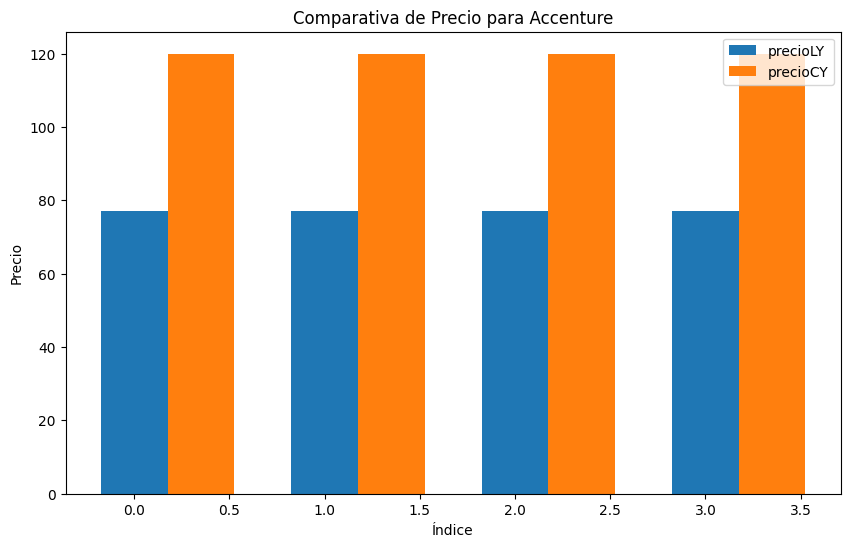

In [ ]:
empresasunicas = plot_df['empresa'].unique()
bar_width = 0.35  # Ancho de las barras
for valempresa in empresasunicas:
    data_empresa = plot_df[plot_df['empresa'] == valempresa]
    indices = range(len(data_empresa))
    plt.figure(figsize=(10, 6))
    plt.bar(indices, data_empresa['precioLY'], width=bar_width, label='precioLY')
    plt.bar([i + bar_width for i in indices], data_empresa['precioCY'], width=bar_width, label='precioCY')
    plt.title(f'Comparativa de Precio para {valempresa}')
    plt.xlabel('Índice')
    plt.ylabel('Precio')
    plt.xticks([i + bar_width / 2 for i in indices], indices)
    plt.legend()
    plt.show()